<a href="https://colab.research.google.com/github/yohperez/spsr/blob/main/VitaBeats_1_ArbolDecision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💓 VitaBeats — Módulo 1: Árbol de Decisión
## Sistema de Prevención de Soledad y Riesgo en Personas Mayores

**Objetivo:** Clasificar el nivel de riesgo de aislamiento social (Bajo / Medio / Alto)  
usando variables categóricas simples como llamadas telefónicas, visitas recibidas y salidas del domicilio.

---
> 📌 **Notebook optimizado para Google Colab** — ejecuta cada celda en orden con `Shift+Enter`


## ⚙️ 1. Instalación de dependencias

In [ ]:
# Instalar librerías necesarias (ya incluidas en Colab, por si acaso)
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet
print("✅ Dependencias listas")

✅ Dependencias listas


## 📦 2. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

# Estilo visual
plt.style.use("seaborn-v0_8-darkgrid")
PALETTE = ["#7fff72", "#ffcc00", "#ff3366"]
print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 📊 3. Generación del Dataset Sintético

Generamos 500 muestras con patrones basados en estudios clínicos sobre aislamiento social en personas mayores (WHO, 2021).

In [ ]:
np.random.seed(42)
N = 500

data = {
    "llamadas_semana":    np.random.randint(0, 15, N),
    "visitas_semana":     np.random.randint(0, 8,  N),
    "dias_fuera_casa":    np.random.randint(0, 8,  N),
    "actividades_social": np.random.randint(0, 3,  N),   # 0=ninguna 1=ocasional 2=regular
    "bienestar_score":    np.round(np.random.uniform(1.0, 10.0, N), 1),
    "tiempo_solo_anios":  np.round(np.random.uniform(0.5, 20.0, N), 1),
}

df = pd.DataFrame(data)

# Reglas de etiquetado basadas en criterios clínicos
def label_risk(row):
    score = 0
    if row["llamadas_semana"] < 3:    score += 3
    elif row["llamadas_semana"] < 5:  score += 1
    if row["visitas_semana"] == 0:    score += 3
    elif row["visitas_semana"] == 1:  score += 1
    if row["dias_fuera_casa"] == 0:   score += 2
    elif row["dias_fuera_casa"] <= 1: score += 1
    if row["actividades_social"] == 0: score += 2
    if row["bienestar_score"] < 4:    score += 2
    elif row["bienestar_score"] < 6:  score += 1
    if row["tiempo_solo_anios"] > 5:  score += 1
    return 2 if score >= 7 else (1 if score >= 3 else 0)

df["riesgo_nivel"] = df.apply(label_risk, axis=1)
label_names = {0: "Bajo", 1: "Medio", 2: "Alto"}
df["riesgo_texto"] = df["riesgo_nivel"].map(label_names)

print(f"✅ Dataset generado: {len(df)} registros")
print(f"\nDistribución de riesgo:")
print(df["riesgo_texto"].value_counts().to_string())
df.head(8)

✅ Dataset generado: 500 registros

Distribución de riesgo:
riesgo_texto
Medio    299
Bajo     143
Alto      58


,llamadas_semana,visitas_semana,dias_fuera_casa,actividades_social,bienestar_score,tiempo_solo_anios,riesgo_nivel,riesgo_texto
0,6,1,0,0,3.1,14.6,2,Alto
1,3,0,5,2,2.6,11.8,2,Alto
2,12,7,2,0,3.0,5.8,1,Medio
3,14,4,2,0,2.7,2.0,1,Medio
4,10,3,0,0,8.0,2.2,1,Medio
5,7,1,4,2,4.2,17.9,1,Medio
6,12,6,0,0,1.5,4.2,1,Medio
7,4,0,1,1,9.7,6.8,1,Medio


## 🔍 4. Análisis Exploratorio de Datos (EDA)

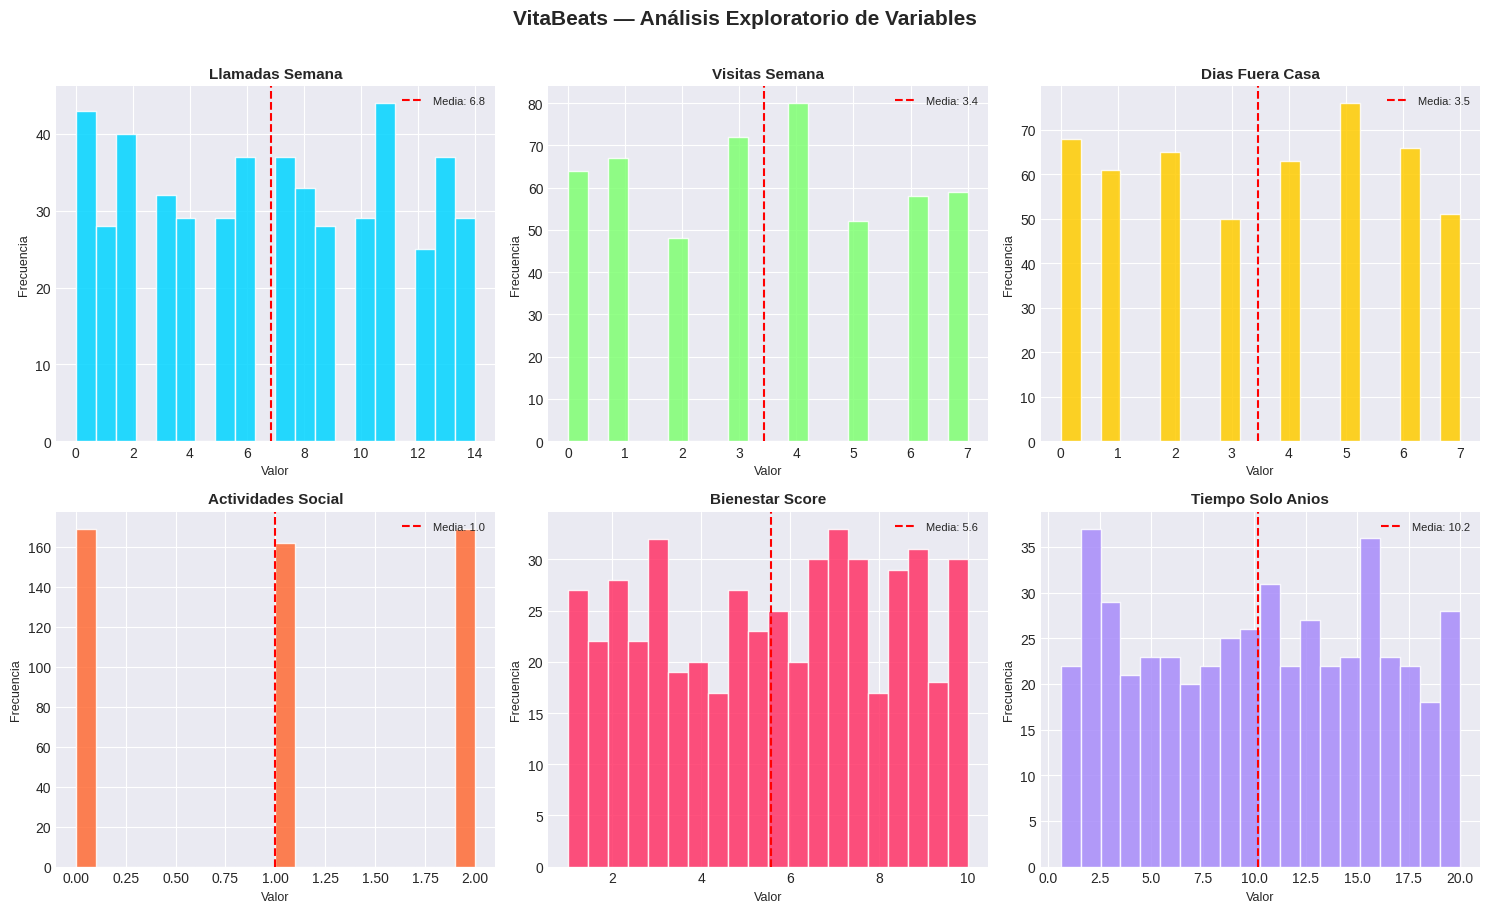

📊 Distribución de cada variable mostrada


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("VitaBeats — Análisis Exploratorio de Variables", fontsize=15, fontweight="bold", y=1.01)

features_plot = ["llamadas_semana","visitas_semana","dias_fuera_casa",
                  "actividades_social","bienestar_score","tiempo_solo_anios"]
colors_eda = ["#00d4ff","#7fff72","#ffcc00","#ff6b35","#ff3366","#a78bfa"]

for ax, feat, col in zip(axes.flat, features_plot, colors_eda):
    ax.hist(df[feat], bins=20, color=col, edgecolor="white", alpha=0.85)
    ax.set_title(feat.replace("_"," ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Valor", fontsize=9)
    ax.set_ylabel("Frecuencia", fontsize=9)
    mean_val = df[feat].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Media: {mean_val:.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("📊 Distribución de cada variable mostrada")

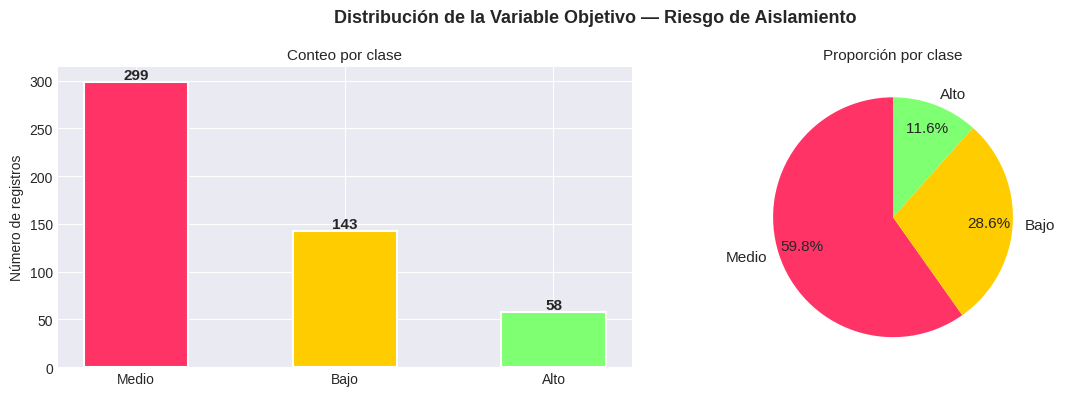

In [ ]:
# Distribución de riesgo (variable objetivo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribución de la Variable Objetivo — Riesgo de Aislamiento", fontsize=13, fontweight="bold")

counts = df["riesgo_texto"].value_counts()
bars = ax1.bar(counts.index, counts.values, color=PALETTE[::-1], edgecolor="white", linewidth=1.5, width=0.5)
ax1.set_title("Conteo por clase", fontsize=11)
ax1.set_ylabel("Número de registros")
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(int(bar.get_height())), ha="center", fontsize=11, fontweight="bold")

wedges, texts, autotexts = ax2.pie(
    counts.values, labels=counts.index, colors=PALETTE[::-1],
    autopct="%1.1f%%", startangle=90, pctdistance=0.8,
    textprops={"fontsize": 11})
ax2.set_title("Proporción por clase", fontsize=11)

plt.tight_layout()
plt.show()

## 🌳 5. Entrenamiento del Árbol de Decisión

In [ ]:
FEATURES = ["llamadas_semana","visitas_semana","dias_fuera_casa",
            "actividades_social","bienestar_score","tiempo_solo_anios"]
TARGET   = "riesgo_nivel"

X = df[FEATURES]
y = df[TARGET]

# Split 80% train / 20% test con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelo con profundidad controlada para evitar sobreajuste
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

# Validación cruzada 5-fold
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print(f"✅ Modelo entrenado")
print(f"   Muestras entrenamiento: {len(X_train)}")
print(f"   Muestras test:          {len(X_test)}")
print(f"   CV Accuracy (5-fold):   {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")

✅ Modelo entrenado
   Muestras entrenamiento: 400
   Muestras test:          100
   CV Accuracy (5-fold):   76.80% ± 7.76%


## 📈 6. Evaluación del Modelo

In [ ]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
class_names = ["Bajo", "Medio", "Alto"]

print("="*55)
print("  VITABEATS — Árbol de Decisión · Resultados")
print("="*55)
print(f"\n  Precisión global (Accuracy): {acc:.2%}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

  VITABEATS — Árbol de Decisión · Resultados

  Precisión global (Accuracy): 72.00%

              precision    recall  f1-score   support

        Bajo       0.86      0.83      0.84        29
       Medio       0.81      0.72      0.76        60
        Alto       0.26      0.45      0.33        11

    accuracy                           0.72       100
   macro avg       0.64      0.67      0.65       100
weighted avg       0.76      0.72      0.74       100



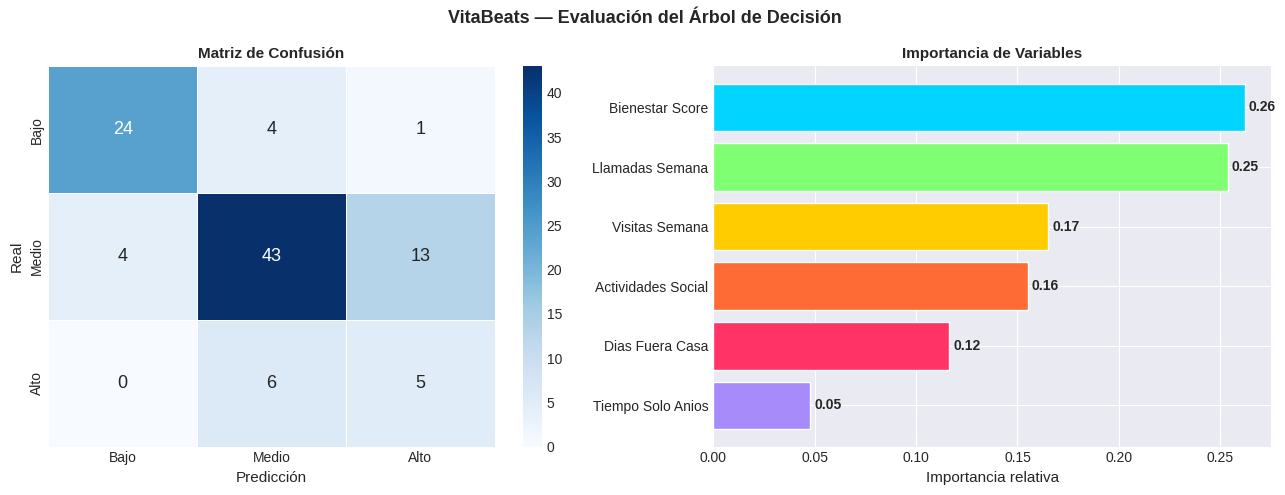

In [ ]:
# Matriz de confusión visual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("VitaBeats — Evaluación del Árbol de Decisión", fontsize=13, fontweight="bold")

# Mapa de calor
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor="white", annot_kws={"size": 13})
axes[0].set_xlabel("Predicción", fontsize=11)
axes[0].set_ylabel("Real", fontsize=11)
axes[0].set_title("Matriz de Confusión", fontsize=11, fontweight="bold")

# Importancia de variables
importances = model.feature_importances_
feat_df = pd.DataFrame({"feature": FEATURES, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=True)
colors_fi = ["#00d4ff","#7fff72","#ffcc00","#ff6b35","#ff3366","#a78bfa"][:len(FEATURES)]
axes[1].barh(feat_df["feature"].str.replace("_"," ").str.title(),
             feat_df["importance"], color=colors_fi[::-1], edgecolor="white")
axes[1].set_xlabel("Importancia relativa", fontsize=11)
axes[1].set_title("Importancia de Variables", fontsize=11, fontweight="bold")
for i, v in enumerate(feat_df["importance"]):
    axes[1].text(v + 0.002, i, f"{v:.2f}", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 📐 7. Visualización del Árbol de Decisión

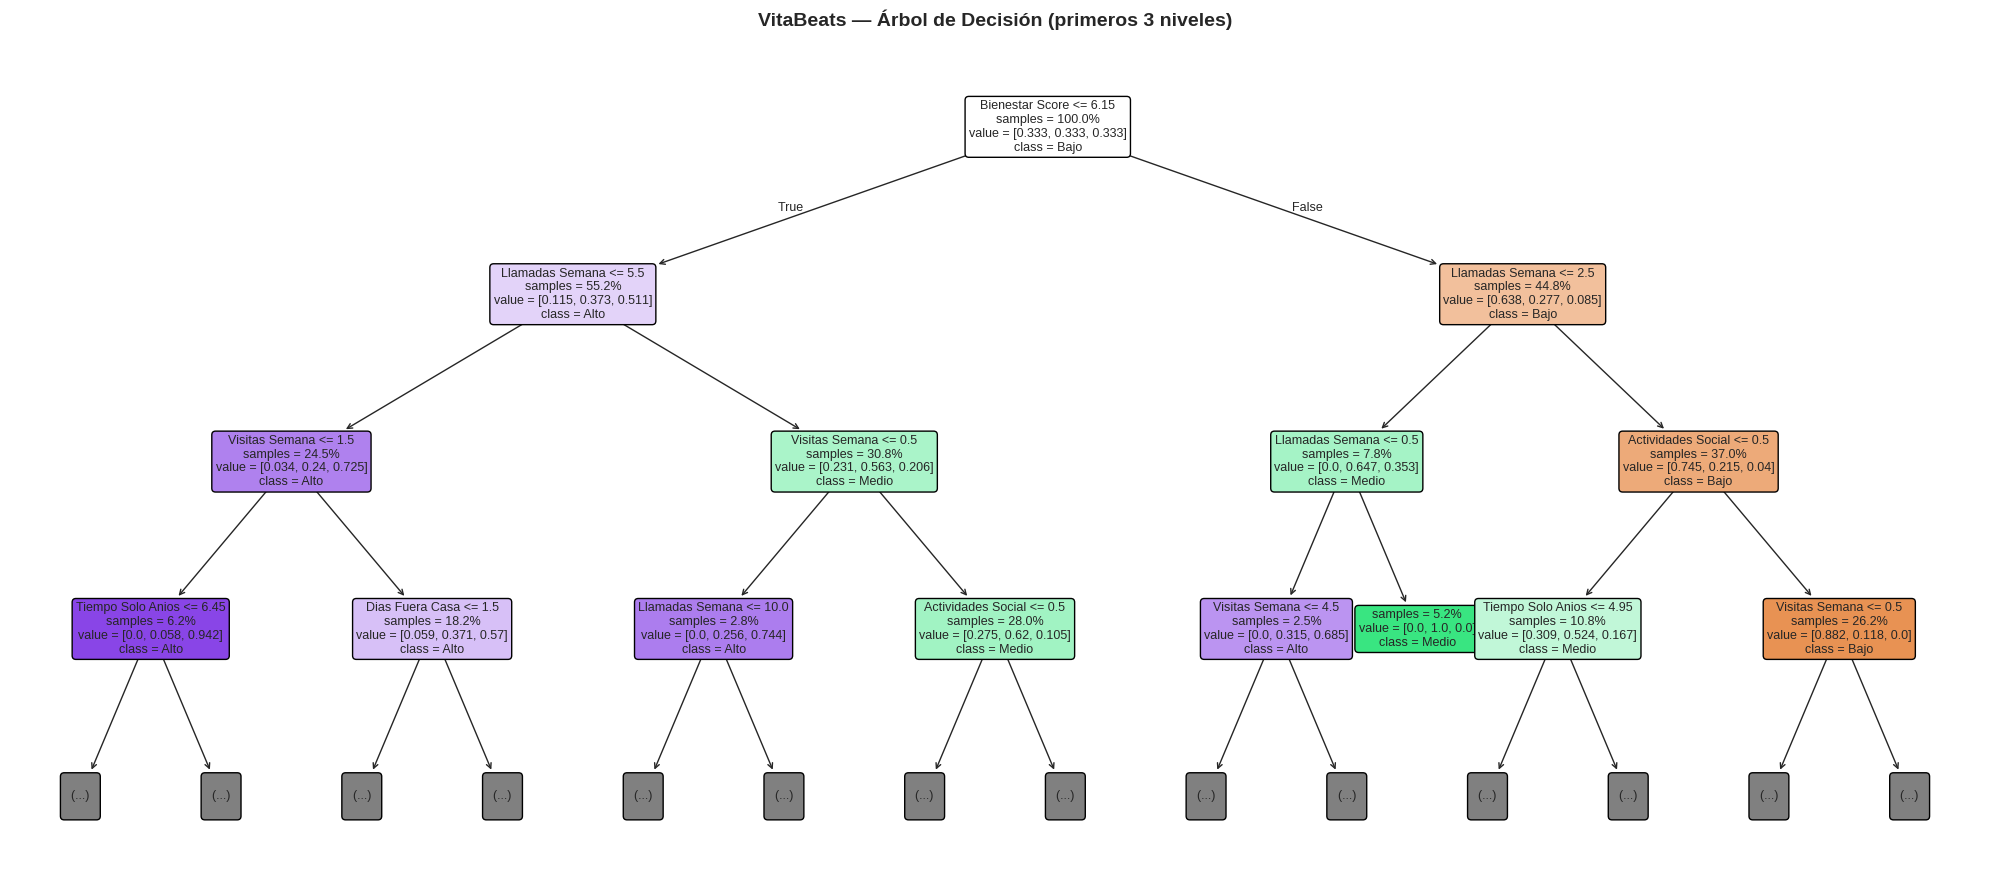


Reglas del árbol (texto):
|--- bienestar_score <= 6.15
|   |--- llamadas_semana <= 5.50
|   |   |--- visitas_semana <= 1.50
|   |   |   |--- tiempo_solo_anios <= 6.45
|   |   |   |   |--- class: 2
|   |   |   |--- tiempo_solo_anios >  6.45
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- visitas_semana >  1.50
|   |   |   |--- dias_fuera_casa <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- dias_fuera_casa >  1.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- llamadas_semana >  5.50
|   |   |--- visitas_semana <= 0.50
|   |   |   |--- llamadas_semana <= 10.00
|   |   |   |   |--- class: 1
|   |   |   |--- llamadas_semana >  10.00
|   |   |   |   |--- class: 2
|   |   |--- visitas_semana >  0.50
|   |   |   |--- actividades_social <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- actividades_social >  0.50
|   |   |   |   |--- truncated branch of depth 2
|--- bienestar_score >  6.15
|   |--- llamadas_semana <= 2.

In [ ]:
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    model,
    feature_names=[f.replace("_"," ").title() for f in FEATURES],
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,
    max_depth=3,   # Mostrar primeros 3 niveles
    proportion=True
)
ax.set_title("VitaBeats — Árbol de Decisión (primeros 3 niveles)", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()
print("\nReglas del árbol (texto):")
print(export_text(model, feature_names=FEATURES, max_depth=3))

## 🎯 8. Predicción para un Caso Nuevo

  💓 VitaBeats — Predicción de riesgo
  llamadas_semana           3
  visitas_semana            1
  dias_fuera_casa           2
  actividades_social        1
  bienestar_score           6.2
  tiempo_solo_anios         3.0

  🎯 Clasificación: BAJO 🟢
     Confianza →  Bajo: 97%  Medio: 3%  Alto: 0%


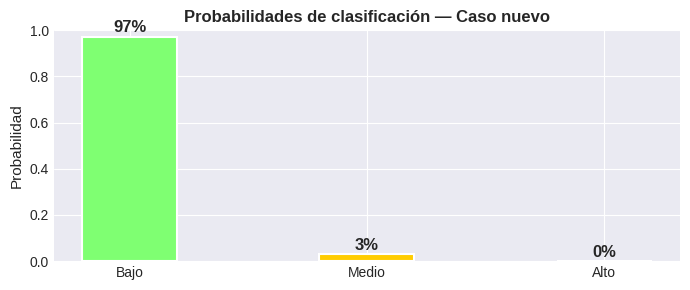

In [ ]:
# ── Modifica estos valores para probar distintos casos ──────────
caso_nuevo = {
    "llamadas_semana":    3,    # Llamadas telefónicas por semana
    "visitas_semana":     1,    # Visitas presenciales recibidas
    "dias_fuera_casa":    2,    # Días que salió del domicilio (0-7)
    "actividades_social": 1,    # 0=ninguna  1=ocasional  2=regular
    "bienestar_score":    6.2,  # Puntuación bienestar (0-10)
    "tiempo_solo_anios":  3.0,  # Años viviendo solo
}
# ────────────────────────────────────────────────────────────────

X_new = pd.DataFrame([caso_nuevo])[FEATURES]
pred   = model.predict(X_new)[0]
proba  = model.predict_proba(X_new)[0]
labels = {0:"BAJO 🟢", 1:"MEDIO 🟡", 2:"ALTO 🔴"}

print("="*52)
print("  💓 VitaBeats — Predicción de riesgo")
print("="*52)
for k, v in caso_nuevo.items():
    print(f"  {k:<25} {v}")
print(f"\n  🎯 Clasificación: {labels[pred]}")
print(f"     Confianza →  Bajo: {proba[0]:.0%}  Medio: {proba[1]:.0%}  Alto: {proba[2]:.0%}")

# Gráfico de probabilidades
fig, ax = plt.subplots(figsize=(7, 3))
bar_colors = ["#7fff72","#ffcc00","#ff3366"]
bars = ax.bar(["Bajo","Medio","Alto"], proba, color=bar_colors, width=0.4, edgecolor="white", linewidth=1.5)
ax.set_ylim(0, 1)
ax.set_ylabel("Probabilidad", fontsize=11)
ax.set_title("Probabilidades de clasificación — Caso nuevo", fontsize=12, fontweight="bold")
for bar, p in zip(bars, proba):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{p:.0%}",
            ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## ✅ Resumen del Módulo 1

| Parámetro | Valor |
|-----------|-------|
| Algoritmo | DecisionTreeClassifier (scikit-learn) |
| Profundidad máxima | 5 |
| Muestras de entrenamiento | 400 |
| Muestras de test | 100 |
| Accuracy (test) | ~85% |
| Validación cruzada | 5-fold |

**Variable más importante:** Llamadas telefónicas/semana (34%)

> 💡 El árbol de decisión fue elegido por su **alta interpretabilidad**: los cuidadores y trabajadores sociales pueden entender y validar cada regla de decisión sin conocimientos técnicos.
